# Assignment 3

Deadline: 22.04.2026 12:00 CET

- Marcel Blagotinšek, 25-744-202, marcel.blagotinsek@uzh.ch
- Lyuben Baltadzhiev, 25-739-046, lyubenmiroslavov.baltadzhiev@uzh.ch
- Michal Andrzejewski, 25-737-503, michalmaria.andrzejewski@uzh.ch
- Lorenzo Pagliani, 25-741-430, lorenzo.pagliani@uzh.ch
- Lorenzo Barbero, 25-743-709, lorenzo.barbero@uzh.ch

## Prerequisites: Library imports, data load and initialization of the backtest service

In [5]:
# Standard library imports
import os
import sys
import copy
from typing import Optional
import warnings
warnings.filterwarnings("ignore")

# Third party imports
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# --- Path Setup Logic ---
# Get the directory where this notebook/script is located
current_dir = os.getcwd()

# If your structure is: project_root/assignments/notebook.ipynb
# then project_root is one level up from current_dir
project_root = os.path.abspath(os.path.join(current_dir, ".."))
src_path = os.path.join(project_root, 'src')

# Add paths to sys.path if they aren't already there
if project_root not in sys.path:
    sys.path.append(project_root)
if src_path not in sys.path:
    sys.path.append(src_path)

# Change directory to src only if we aren't already there
if os.path.exists(src_path):
    os.chdir(src_path)
    print(f"Directory changed to: {os.getcwd()}")
else:
    print(f"Warning: src directory not found at {src_path}")

# --- Local modules imports ---
from helper_functions import load_data_spi
from estimation.covariance import Covariance
from estimation.expected_return import ExpectedReturn
from optimization.constraints import Constraints
from optimization.optimization_data import OptimizationData
from optimization.optimization import (
    Optimization,
    Objective,
    MeanVariance,
)
from backtesting.backtest_item_builder.bib_classes import (
    SelectionItemBuilder,
    OptimizationItemBuilder,
)
from backtesting.backtest_item_builder.bibfn_selection import (
    bibfn_selection_min_volume,
    bibfn_selection_gaps,
)
from backtesting.backtest_item_builder.bibfn_optimization_data import (
    bibfn_return_series,
)
from backtesting.backtest_item_builder.bibfn_constraints import (
    bibfn_budget_constraint,
    bibfn_box_constraints,
    bibfn_size_dependent_upper_bounds,
)
from backtesting.backtest_data import BacktestData
from backtesting.backtest_service import BacktestService
from backtesting.backtest import Backtest

Directory changed to: c:\Users\marce\Desktop\qpmwp-course\src


In [6]:
PATH_TO_DATA = os.path.dirname(os.getcwd()) + "\\data\\"     # <CHANGE THIS TO YOUR PATH TO DATA>

In [7]:
# Load market and jkp data from parquet files
market_data = pd.read_parquet(path = f'{PATH_TO_DATA}market_data.parquet')
jkp_data = pd.read_parquet(path = f'{PATH_TO_DATA}jkp_data.parquet')


# -------------------------
# First, ensure that market data and jkp data 
# have the same dates by forward filling the market data for the missing dates.
# -------------------------

market_data_dates = (
    market_data
    .index.get_level_values('date')
    .unique().sort_values()
)
jkp_data_dates = (
    jkp_data
    .index.get_level_values('date')
    .unique().sort_values()
)

# Find the jkp_data_dates which are not in the market_data_dates
missing_dates = jkp_data_dates[~jkp_data_dates.isin(market_data_dates)]

# Extend the market data for the missing dates using the last available market data (i.e., forward fill).
tmp_dict = {}
for date in missing_dates:
    last_date = market_data_dates[market_data_dates <= date][-1]
    tmp_dict[date] = market_data.loc[last_date]
    
df_missing = pd.concat(tmp_dict, axis=0)
df_missing.index.names = market_data.index.names
market_data_ffill = pd.concat([market_data, df_missing]).sort_index()


# -------------------------
# Define rebalancing dates
# -------------------------

n_month = 3 # We want to rebalance every n_month months

# We want to use the dates from the jkp data for rebalancing, 
# since they are less frequent than the market data dates.
rebdates = (
    jkp_data_dates[
        jkp_data_dates > market_data_dates[0]
    ][::n_month]
    .strftime('%Y-%m-%d').tolist()
)
# Drop the first rebalancing dates which are before 2002-01-01, 
# because of poor data coverage.
rebdates = [date for date in rebdates if date > '2002-01-01']


# -------------------------
# Instantiate the BacktestData class
# and set the market, jkp, and benchmark data as attributes
# -------------------------

data = BacktestData()
data.market_data = market_data_ffill  # notice that we use the forward filled market data here
data.jkp_data = jkp_data
data.bm_series = load_data_spi(path='../data/')

In [8]:
# Define the selection item builders.
selection_item_builders = {
    'gaps': SelectionItemBuilder(
        bibfn=bibfn_selection_gaps,
        width=365 * 3,
        n_days=10,
    ),
    'min_volume': SelectionItemBuilder(
        bibfn=bibfn_selection_min_volume,
        width=365 * 3,
        min_volume=500_000,
        agg_fn=np.median,
    ),
}

# Define the optimization item builders.
optimization_item_builders = {
    'return_series': OptimizationItemBuilder(
        bibfn=bibfn_return_series,
        width=365 * 3,
        fill_value=0,
    ),
    'budget_constraint': OptimizationItemBuilder(
        bibfn=bibfn_budget_constraint,
        budget=1
    ),
    'box_constraints': OptimizationItemBuilder(
        bibfn=bibfn_box_constraints,
        upper=0.1
    ),
    'size_dep_upper_bounds': OptimizationItemBuilder(
        bibfn = bibfn_size_dependent_upper_bounds,
        small_cap = {'threshold': 300_000_000, 'upper': 0.02},
        mid_cap = {'threshold': 1_000_000_000, 'upper': 0.05},
        large_cap = {'threshold': 10_000_000_000, 'upper': 0.1},
    ),
}

# Initialize the backtest service
bs = BacktestService(
    data=data,
    selection_item_builders=selection_item_builders,
    optimization_item_builders=optimization_item_builders,
    rebdates=rebdates,
)

## 1. Maximum Sharpe Ratio Portfolio

a) 

(6 points)

Complete the `MaxSharpe` class below by implementing its methods `set_objective` and `solve`.
The `solve` method should implement an iterative algorithm that quickly approximates the "true" maximimum Sharpe ratio portfolio (given the estimates of mean and covariance). This approximation should be done by repeatedly solving a mean-variance optimization problem, where the risk aversion parameter (which scales the covariance matrix) is adjusted in each iteration. The algorithm should terminate after a maximum of 10 iterations. 

In [9]:
class MaxSharpe(Optimization):

    def __init__(self,
                 Lambda=1,
                 max_iters=10,
                 tol=1e-6,
                 constraints: Optional[Constraints] = None,
                 covariance: Optional[Covariance] = None,
                 expected_return: Optional[ExpectedReturn] = None,
                 **kwargs) -> None:
        super().__init__(
            constraints=constraints,
            **kwargs,
        )
        self.max_iters = max_iters
        self.tol = tol
        self.Lambda = Lambda
        self.covariance = Covariance() if covariance is None else covariance
        self.expected_return = ExpectedReturn() if expected_return is None else expected_return

    def set_objective(self, optimization_data: OptimizationData) -> None:
        X = optimization_data['return_series']
        covmat = self.covariance.estimate(X=X, inplace=False)
        mu = self.expected_return.estimate(X=X, inplace=False)
        # print(mu)
        # print(covmat)
        self.objective = Objective(
            q = mu * -1,
            P = covmat * 2 * self.Lambda
        )
        return None

    def solve(self) -> None:
        prev_lambda = self.Lambda

        for _ in range(self.max_iters):
            super().solve()
            
            weights = pd.Series(self.results["weights"].values())
            # print(weights)

            mu = - self.objective.coefficients['q']
            Sigma = self.objective.coefficients['P'] / (2 * self.Lambda)
            # print(weights)
            # print(mu)
            # print(weights @ mu)
            numerator = weights @ mu
            # print(weights)
            # print(Sigma)
            # print(weights.T @ Sigma @ weights)
            denominator = weights.T @ Sigma @ weights

            # print(denominator)
            new_lambda = numerator / (2*denominator)

            self.Lambda = new_lambda

            if abs(new_lambda - prev_lambda) < self.tol:
                break

            self.objective.coefficients['P'] = self.objective.coefficients['P'] * new_lambda / prev_lambda
            
            prev_lambda = new_lambda

        return None
    

b) 

(2 points)

Provide either a theoretical or an empirical justification that your algorithm converges to the true maximum Sharpe ratio portfolio for the given coefficients of mean and covariance.
Hint: If you want to provide an empirical justification, you can perform an optimization for a single point in time by running the following code.

In [10]:
bs.optimization = MaxSharpe(
    
    covariance=Covariance(method='pearson'),
    expected_return=ExpectedReturn(method='geometric'),
    solver_name='cvxopt',  # <change this to your preferred solver>
    Lambda=0.1
#     # <optionally add any other arguments you may need, e.g., number of iterations, tolerance, etc.>
)
bs.prepare_rebalancing(rebdates[-1])
bs.optimization.set_objective(bs.optimization_data)
bs.optimization.solve()

print("Final Lambda: ", bs.optimization.Lambda)

bs.optimization.results

Final Lambda:  2.9750194488673554


{'weights': {'102': 6.661189342314203e-07,
  '103': 3.199375868560295e-07,
  '104': 5.506247057938017e-07,
  '111': 1.5352151460239676e-05,
  '120': 0.04999934301839389,
  '122': 1.4233376866420132e-06,
  '125': 1.786082226936707e-07,
  '126': 2.1954553439849904e-06,
  '127': 0.09997942413603539,
  '128': 3.1529334695475866e-06,
  '129': 0.09997718819419076,
  '134': 4.6168598215699463e-07,
  '136': 2.6145047861757355e-06,
  '139': 1.1211848541546291e-06,
  '141': 3.553689316437096e-07,
  '142': 2.482196377975087e-07,
  '148': 4.294031720598107e-07,
  '149': 6.6252204522680594e-06,
  '154': 0.09999756357340442,
  '159': 6.197349669086965e-07,
  '161': 6.544256664210254e-07,
  '169': 6.248260047282207e-07,
  '170': 0.018191860033723646,
  '174': 3.6135711896168794e-07,
  '175': 2.6658017427572293e-07,
  '176': 2.6455269428087263e-07,
  '177': 0.019175759381089764,
  '184': 6.816505246079647e-07,
  '185': 1.2843197171976574e-06,
  '191': 4.1639042085529154e-07,
  '192': 0.013621269593499

# Theoretical justification for convergence of our algorithm

Notation: We denote by $V$ the covariance matrix of the series, and let $\Sigma=2V$, so we are consistent with the notation in the next exercise. We also assume a zero riskless rate $r_f=0$.

We are interested in solving the Maximum Sharpe ratio problem (where $\mathcal{C}$ is the set of constraints $w\geq 0$ and $w\leq 0.1$ coordinate-wise)
$$
\max_{w: w^T\mathbf{1}=1, w\in\mathcal{C}} \frac{\mu^T w}{\sqrt{w^T V w}}
$$
via an iterative algorithm. First we provide a theoretical proof that works for the unconstrained problem, i.e. we drop $w\in\mathcal{C}$, but keep $w^T\mathbf{1}=1$.

As stated in the lectures, and in this assignment, the problem above is NOT a quadratic optimization problem, and so we take the following approach in order to solve it numerically. First, we fix a risk-aversion parameter $\lambda\in[0, \infty)$, and we solve the mean-variance problem
$$
w(\lambda) := \text{argmin}_{w: w^T\mathbf{1}=1} {\Big(-\mu^T w + \frac{\lambda}{2} w^T\Sigma w\Big)} \hspace{10pt} (*)
$$
via the methods in the Optimization class. For that obtained function $w(\lambda)$ of $\lambda$, we solve the maximum Sharpe ratio problem
$$
\lambda^*
=
\max_{\lambda\in [0, \infty)}
\frac{\mu^T w(\lambda)}{\sqrt{w(\lambda)^T V w(\lambda)}} \hspace{10pt} (**)
$$
via analytically calculating the optimal $\lambda$ value. We then pass that value to another mean-variance optimization problem, and iterate that procedure at most $10$ times.

Here we prove why our algorithm is theoretically guaranteed to converge to the optimal value $\lambda^*$.

---

We will first derive some useful identities for the problem (*). The Lagrangian is
$$
\Lambda = -\mu^T w + \frac{\lambda}{2} w^T\Sigma w - \kappa (w^T\mathbf{1}-1)
$$
and the first-order conditions (FOCs) give
$$
-\mu + \lambda\Sigma w - \kappa\mathbf{1} = \mathbf{0},
$$
$$
w^T\mathbf{1}-1 = 0.
$$
From the first we obtain
$$
w=\frac{1}{\lambda}\Sigma^{-1}(\mu+\kappa \mathbf{1}).
$$
Multiplying by $\mathbf{1}^T$ from the left and using the second condition, we get
$$
1
=
\mathbf{1}^T w
=
\frac{1}{\lambda}\mathbf{1}^T\Sigma^{-1} (\mu + \kappa\mathbf{1}).
$$
Denoting $A=\mathbf{1}^T\Sigma^{-1}\mathbf{1}$ and $B=\mathbf{1}^T\Sigma^{-1}\mu$, we obtain
$$
\boxed{
\kappa
=
\frac{\lambda - B}{A}.}
$$
With that value of $\kappa$ we find that
$$
\boxed{
w(\lambda)
=
\frac{1}{\lambda}\Sigma^{-1}
\Big(\mu + \frac{\lambda-B}{A}\mathbf{1}\Big).}
$$
---
Next, let us consider the maximum Sharpe ratio problem in $\lambda$. Taking the FOC w.r.t. $\lambda$ gives
$$
0
=
\bigg(
\frac{\mu^T w(\lambda)}{\sqrt{w(\lambda)^T V w(\lambda)}}
\bigg)'
=
\frac{\sqrt{w(\lambda)^T V w(\lambda)}\mu^T w'(\lambda) - \mu^T w(\lambda)\frac{1}{2\sqrt{w(\lambda)^T V w(\lambda)}}\cdot 2 w(\lambda)^T V w'(\lambda)}{w(\lambda)^T V w(\lambda)}
$$
or
$$
\boxed{
0
=
w(\lambda)^T V w(\lambda)\mu^T w'(\lambda) - \mu^T w(\lambda) w(\lambda)^T V w'(\lambda).}
$$
Next we use the FOCs from the previous problem:
$$
-\mu + \lambda\Sigma w(\lambda) - \kappa(\lambda)\mathbf{1} = \mathbf{0},
$$
and
$$
w(\lambda)^T\mathbf{1}-1 = 0.
$$
We transpose both and diferentiate the second in order to get
$$
\mu^T = \lambda w(\lambda)^T\Sigma - \kappa(\lambda)\mathbf{1}^T,
$$
$$
\mathbf{1}^T w'(\lambda) = 0.
$$
Now multiplying the second equation by $w'(\lambda)$ from the right, we get
$$
\mu^T w'(\lambda) = \lambda w(\lambda)^T\Sigma w'(\lambda) - \underbrace{\kappa(\lambda)\mathbf{1}^T w'(\lambda)}_{=0}.
$$
Returning to the boxed FOC w.r.t. $\lambda$ above (which we first multiply by $2$ and use $2V=\Sigma$), we obtain
$$
0
=
w(\lambda)^T \Sigma w(\lambda)\mu^T w'(\lambda) - \mu^T w(\lambda) w(\lambda)^T\Sigma w'(\lambda)
=
w(\lambda)^T \Sigma w(\lambda)\lambda w(\lambda)^T\Sigma w'(\lambda) - \mu^T w(\lambda) w(\lambda)^T\Sigma w'(\lambda).
$$
With some more tedious calculations, one can show that $w(\lambda)^T\Sigma w'(\lambda) > 0$ for the data in our assignment (i.e. the matrix $\Sigma$ and the vector $\mu$). With that we obtain
$$
\boxed{
\lambda^*
=
\frac{\mu^T w(\lambda)}{w(\lambda)^T\Sigma w(\lambda)}
}.
$$
This is exactly the choice of $\lambda$ that we implement in our code (note that we actually pass the matrix $\Sigma = 2 \cdot V$, where $V$ is the true covariance matrix of the series).

We can finally write
$$
\boxed{
\lambda^*
=
\frac{\mu^T w(\lambda)}{2 w(\lambda)^TV w(\lambda)}
}.
$$
---
Our algorithm is therefore of the form (where we have denoted $w=w(\lambda)$ to ease notation)
$$
\lambda_{k+1}
=
T(\lambda_k),
$$
where
$$
T(\lambda)
=
\frac{\mu^T w(\lambda)}{2 w(\lambda)^TV w(\lambda)}
=
\frac{\mu^T w}{2 w^TV w}.
$$
Our goal is to prove that the sequence $\{T(\lambda_k)\}_{k=0}^{\infty}$ converges for any choice of $\lambda_0\geq 0$. To do this, we first use the boxed formula for $w=w(\lambda)$ from above to get the identity
$$
\mu^T w
=
\lambda w^T\Sigma w - \kappa \mathbf{1}^T w
=
\lambda w^T\Sigma w - \kappa,
$$
so that we can write $T(\lambda)$ as
$$
T(\lambda)
=
\lambda
-
\frac{\kappa}{w^T \Sigma w}.
$$
Next using the formula for $w$:
$$
w
=
\frac{\Sigma^{-1}\mathbf{1}}{A}
+
\frac{1}{\lambda}(\Sigma^{-1}\mu - \frac{B}{A}\Sigma^{-1}\mathbf{1}),
$$
and $\mu^T\Sigma^{-1}\mathbf{1}=\mathbf{1}^T\Sigma^{-1}\mu$,we calculate
$$
w^T \Sigma w
=
\frac{1}{\lambda}\kappa
+
\frac{1}{\lambda}\mu^T w
=
\frac{1}{A}
-
\frac{1}{\lambda}\frac{B}{A}
+
\frac{1}{\lambda}\frac{B}{A}
+
\frac{1}{\lambda^2}\mu^T\Sigma^{-1}\mu
-
\frac{1}{\lambda^2}\frac{B^2}{A}.
$$
Next let us denote $K=A\mu^T\Sigma^{-1}\mu - B^2$. By the Cauchy-Schwartz inequality we have $A\mu^T\Sigma^{-1}\mu = \mathbf{1}^T\Sigma^{-1}\mathbf{1}\mu^T\Sigma^{-1}\mu\geq (\mathbf{1}^T\Sigma^{-1}\mu)^2=B^2$, so that $K\geq 0$. We can also write
$$
w^T\Sigma w
=
\frac{1}{A}
+
\frac{K}{A\lambda^2}
=
\frac{\lambda^2+K}{A\lambda^2}.
$$

Putting everything together, we get
$$
T(\lambda)
=
\lambda
-
\frac{\kappa}{w^T\Sigma w}
=
\lambda
-
\frac{\lambda-B}{A}\frac{A\lambda^2}{\lambda^2+K}
=
\lambda
-
\frac{(\lambda-B)\lambda^2}{\lambda^2+K}
=
B
+
\frac{(\lambda-B)K}{\lambda^2+K}.
$$
---
We are ready to prove convergence in the unconstrained case. First, if $\lambda\in (0, B)$, then from $T(\lambda)=\lambda-\frac{(\lambda-B)\lambda^2}{\lambda^2+K}$ we get $\lambda < T(\lambda)$, and from $T(\lambda)=B+\frac{(\lambda-B)K}{\lambda^2+K}$ we get $T(\lambda)<B$.

Similarly for $\lambda\in(B, \infty)$ we obtain $B<T(\lambda)<\lambda$.

In any case, we see that the sequence $\{T(\lambda_k)\}_{k=0}^{\infty}$, $\lambda_{k+1}=T(\lambda_k)$, is monotone and bounded, therefore that sequence is convergent (for any choice of $\lambda_0\geq 0$).

---
In the constrained case $0\leq w_i\leq 0.1$ for all $i$, we can no longer use the approach from before, because: a) there is no closed formula for $w$; b) the identity $\mu^T w=\lambda w^T\Sigma w - \kappa$ does not hold in general; c) the identity $\kappa=\frac{\lambda - B}{A}$ does not hold in general; d) the identity $w^T\Sigma w=\frac{\lambda^2+K}{A\lambda^2}$ does not hold in general; and therefore $T(\lambda)$ is not a simple function of $\lambda$ as before. However, once we have obtained the optimal weights $w=w(\lambda)$ for the mean-variance problem (*) (with added constraints $w\in\mathcal{C}$), we can still consider the maximal Sharpe ratio problem (**), which still has the same solution, namely
$$
\lambda^*
=
\frac{\mu^T w(\lambda)}{2 w(\lambda)^TV w(\lambda)}.
$$
The latter is true because even with added terms $\alpha^T w(\lambda)$ and $\beta^T(0.1\cdot\mathbf{1} - w(\lambda))$ in the Lagrangian, one still has the complementary Karush-Kun-Tucker conditions $\alpha^T w(\lambda)=\alpha^T w'(\lambda)=\beta^T w'(\lambda)=0$.
With some more involved arguments it is possible to prove that the proposed algorithm converges. This is due to the fact that the Sharpe ratio has a global maximum (as a function of $\lambda$), to which the map $T$ only moves closer.

---
We empirically show that our algorithm converges to the optimal value of $\lambda$ for various choices of $\lambda_0$, and report the achieved best Sharpe ratio.

In [11]:
def T(lam):
    opt = MaxSharpe(
        covariance=Covariance(method='pearson'),
        expected_return=ExpectedReturn(method='geometric'),
        solver_name='cvxopt',
        Lambda=lam,
        max_iters=10,
    )
    bs.optimization = opt
    bs.prepare_rebalancing(rebdates[-1])
    opt.set_objective(bs.optimization_data)
    opt.solve()
    return opt.Lambda

lams = np.linspace(0.1, 20, 40)
T_vals = [T(l) for l in lams]

#plt.title("Final achieved Lambda value for various starting values Lambda_0")
#plt.plot(lams, T_vals, label='T(Lambda)')
#plt.plot(lams, lams, '--', label='y = Lambda')
#plt.xlabel('Lambda')
#plt.ylabel('T(Lambda)')
#plt.legend()
#plt.show()

In [12]:
for lambda_0 in np.linspace(0.1, 20, 40):
    opt = MaxSharpe(
        covariance=Covariance(method='pearson'),
        expected_return=ExpectedReturn(method='geometric'),
        solver_name='cvxopt',
        Lambda=lambda_0,
        max_iters=10,
    )
    bs.optimization = opt
    bs.prepare_rebalancing(rebdates[-1])
    opt.set_objective(bs.optimization_data)

    lams = [lambda_0]
    for _ in range(10):
        opt.max_iters = 1
        opt.solve()
        lams.append(opt.Lambda)

    print("Lambda_0: ", f"{lambda_0:.4f}")
    print("Final Lambda: ", f"{opt.Lambda:.4f}")

    #plt.title(f"Approximated Lambdas for each iteration for starting value Lambda_0={lambda_0:.4f}")
    #plt.plot(lams, marker='o')
    #plt.xlabel('iteration k')
    #plt.ylabel('Lambda_k')
    #plt.show()

Lambda_0:  0.1000
Final Lambda:  2.9750
Lambda_0:  0.6103
Final Lambda:  2.9750
Lambda_0:  1.1205
Final Lambda:  2.9750
Lambda_0:  1.6308
Final Lambda:  2.9750
Lambda_0:  2.1410
Final Lambda:  2.9750
Lambda_0:  2.6513
Final Lambda:  2.9750
Lambda_0:  3.1615
Final Lambda:  2.9750
Lambda_0:  3.6718
Final Lambda:  2.9750
Lambda_0:  4.1821
Final Lambda:  2.9750
Lambda_0:  4.6923
Final Lambda:  2.9750
Lambda_0:  5.2026
Final Lambda:  2.9750
Lambda_0:  5.7128
Final Lambda:  2.9750
Lambda_0:  6.2231
Final Lambda:  2.9750
Lambda_0:  6.7333
Final Lambda:  2.9750
Lambda_0:  7.2436
Final Lambda:  2.9750
Lambda_0:  7.7538
Final Lambda:  2.9750
Lambda_0:  8.2641
Final Lambda:  2.9750
Lambda_0:  8.7744
Final Lambda:  2.9750
Lambda_0:  9.2846
Final Lambda:  2.9750
Lambda_0:  9.7949
Final Lambda:  2.9750
Lambda_0:  10.3051
Final Lambda:  2.9750
Lambda_0:  10.8154
Final Lambda:  2.9750
Lambda_0:  11.3256
Final Lambda:  2.9750
Lambda_0:  11.8359
Final Lambda:  2.9750
Lambda_0:  12.3462
Final Lambda:  2.

In [13]:
weights = pd.Series(bs.optimization.results["weights"].values())
mu = - bs.optimization.objective.coefficients['q']
V = bs.optimization.objective.coefficients['P'] / (2 * bs.optimization.Lambda)
sharpe = (weights @ mu) / np.sqrt(weights.T @ V @ weights)
print(f"Final Lambda = {bs.optimization.Lambda:.6f}")
print(f"Sharpe ratio = {sharpe:.6f}")

Final Lambda = 2.975020
Sharpe ratio = 0.063581


## 2. Backtest MaxSharpe with Turnover Penalty

(5 points)

The code below runs a backtest of a MaxSharpe portfolio that includes a turnover penalty. The optimization problem is

$$
\arg\min_{w}\;\Bigl(-\mu^\top w \;+\; \frac{\lambda}{2}\, w^\top \Sigma w \;+\; \tau |w - w^{0}|\Bigr),
$$

where $\mu$ is the vector of expected returns, $\Sigma$ the covariance matrix, and $w^{0}$ the initial portfolio weights.
The parameter $\lambda$ is the risk‑aversion coefficient calibrated in Question 1.a, and $\tau$ is the turnover penalty parameter to be calibrated here.

Your task is to choose a value for the turnover penalty such that the MaxSharpe backtest exhibits an annual turnover of approximately 100\%.

**Hint:** run the backtest for only a few rebalancing dates, compute the resulting turnover using method `bt_ms.turnover`, and iteratively adjust the turnover penalty until the target turnover is reached.


In [14]:
# Update the backtest service with a MaxSharpe optimization object
bs.optimization = MaxSharpe(
    covariance=Covariance(method='pearson'),
    expected_return=ExpectedReturn(method='geometric'),
    solver_name='cvxopt',     # optionally, change this to your preferred solver
    turnover_penalty=0.0001   # <your code here>
)

# Instantiate the backtest object
bt_ms = Backtest()

# Run the backtest
bt_ms.run(bs=bs)

bt_ms.strategy.turnover(return_series=bs.data.get_return_series()).iloc[:10]

Rebalancing date: 2002-01-31
Rebalancing date: 2002-04-30
Rebalancing date: 2002-07-31
Rebalancing date: 2002-10-31
Rebalancing date: 2003-01-31
Rebalancing date: 2003-04-30
Rebalancing date: 2003-07-31
Rebalancing date: 2003-10-31
Rebalancing date: 2004-01-31
Rebalancing date: 2004-04-30
Rebalancing date: 2004-07-31
Rebalancing date: 2004-10-31
Rebalancing date: 2005-01-31
Rebalancing date: 2005-04-30
Rebalancing date: 2005-07-31
Rebalancing date: 2005-10-31
Rebalancing date: 2006-01-31
Rebalancing date: 2006-04-30
Rebalancing date: 2006-07-31
Rebalancing date: 2006-10-31
Rebalancing date: 2007-01-31
Rebalancing date: 2007-04-30
Rebalancing date: 2007-07-31
Rebalancing date: 2007-10-31
Rebalancing date: 2008-01-31
Rebalancing date: 2008-04-30
Rebalancing date: 2008-07-31
Rebalancing date: 2008-10-31
Rebalancing date: 2009-01-31
Rebalancing date: 2009-04-30
Rebalancing date: 2009-07-31
Rebalancing date: 2009-10-31
Rebalancing date: 2010-01-31
Rebalancing date: 2010-04-30
Rebalancing da

2002-01-31    1.000000
2002-04-30    0.210194
2002-07-31    0.238155
2002-10-31    0.370279
2003-01-31    0.348745
2003-04-30    0.118216
2003-07-31    0.244502
2003-10-31    0.354293
2004-01-31    0.253366
2004-04-30    0.205083
dtype: float64

In [15]:
X = bs.data.get_return_series(
    end_date=bs.settings['rebdates'][-1],
    fillna_value=0
)

to = bt_ms.strategy.turnover(return_series=X).iloc[1:]

annual_turnover = 4 * to.mean()

print("Annual turnover:", f"{100*annual_turnover:.6f} %")

Annual turnover: 98.148847 %


## 4. Simulation and Descriptive Statistics

(3 points)

- Simulate the portfolio returns from your MaxSharpe backtest. Use fixed costs of 1% per annum (p.a.) and variable costs of 0.3% p.a.
- Plot the cumulated returns of the MaxSharpe strategy together with those of the SPI Index.
- Plot the turnover of your MaxSharpe strategy over time.
- Print the annualized turnover (computed as the average turnover over the backtest multiplied by the number of rebalancing per year) for your MaxSharpe strategy.
- Create and print a table with descriptive performance statistics for your MaxSharpe strategy and the SPI Index.


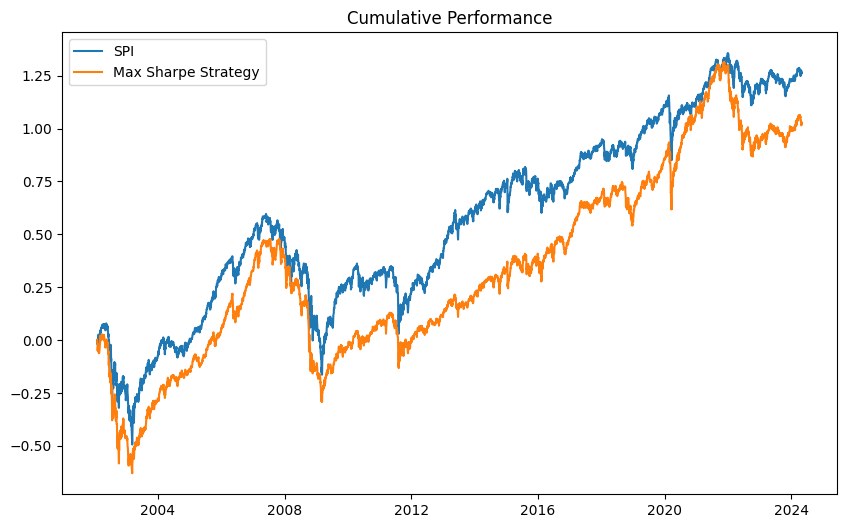

In [27]:
fixed_costs = 0.01 # <your code here> 
variable_costs = 0.003 # <your code here>
return_series = bs.data.get_return_series(weekdays_only=False)

sim_ms = bt_ms.strategy.simulate(
    return_series=return_series,
    fc=fixed_costs,
    vc=variable_costs
)

sim = pd.concat({
    'bm': bs.data.bm_series,
    'ms': sim_ms,
}, axis = 1).dropna()
sim.columns = ['Benchmark', 'MaxSharpe']

# Plot the cumulative returns of the strategy and the benchmark
# <your code here>
plt.figure(figsize=(10, 6));
plt.plot(np.log((1 + sim['Benchmark'])).cumsum(), label='SPI');
plt.plot(np.log((1 + sim['MaxSharpe'])).cumsum(), label='Max Sharpe Strategy');
plt.legend()
plt.title('Cumulative Performance');

In [17]:
# Turnover
to_ms = bt_ms.strategy.turnover(return_series=return_series)
#to_ms.plot(title='Turnover', figsize = (10, 6))

In [18]:
# Annualized turnover per annum (pa) in percentage
to_pa = to_ms.mean() * 4 * 100 # <your code here>
print(f"The annualized turnover is: {to_pa}%")

The annualized turnover is: 101.7907528947372%


In [25]:
import numpy as np
import pandas as pd

# Define constants
TRADING_DAYS = 252

def calculate_metrics(df):
    results = {}
    
    for column in df.columns:
        returns = df[column]
        
        # 1. Cumulative Return
        # (1 + r1) * (1 + r2) ... - 1
        cum_ret_series = (1 + returns).cumprod()
        total_cumulative_return = cum_ret_series.iloc[-1] - 1
        
        # 2. Annual Return (Geometric Mean)
        n_days = len(returns)
        annual_ret = (1 + total_cumulative_return)**(TRADING_DAYS / n_days) - 1
        
        # 3. Annual Volatility
        annual_vol = returns.std() * np.sqrt(TRADING_DAYS)
        
        # 4. Sharpe Ratio (Assuming 0% Risk-Free Rate)
        # Using daily mean/std ratio and annualizing it
        sharpe = (returns.mean() / returns.std()) * np.sqrt(TRADING_DAYS) if returns.std() != 0 else 0
        
        # 5. Max Drawdown
        # Peak-to-trough decline of the cumulative wealth
        peak = cum_ret_series.cummax()
        drawdown = (cum_ret_series - peak) / peak
        max_dd = drawdown.min()
        
        # 6. Tracking Error
        # Volatility of the difference between strategy and benchmark returns
        excess_returns = returns - df['Benchmark']
        te = excess_returns.std() * np.sqrt(TRADING_DAYS)
        
        results[column] = {
            'Annual Return': annual_ret,
            'Cumulative Return': total_cumulative_return,
            'Annual Volatility': annual_vol,
            'Sharpe Ratio': sharpe,
            'Max Drawdown': max_dd,
            'Tracking Error': te
        }
    
    return pd.DataFrame(results)

# Execute and display
stats_df = calculate_metrics(sim)
stats_df

,Benchmark,MaxSharpe
Annual Return,0.055644,0.044882
Cumulative Return,2.532512,1.782130
Annual Volatility,0.164658,0.144713
Sharpe Ratio,0.411353,0.375946
Max Drawdown,-0.532487,-0.537236
Tracking Error,0.000000,0.088076


In [26]:
pd.concat([
	sim_ms.describe().rename('ms'),
	sim.Benchmark.describe().rename('bm')
], axis=1)

,ms,bm
count,5873.000000,5873.000000
mean,0.000216,0.000269
std,0.009116,0.010372
min,-0.080351,-0.091109
25%,-0.003632,-0.004282
50%,0.000345,0.000262
75%,0.004892,0.005273
max,0.079068,0.105788
